  gender_submission.csv — EDA Report

  Total Passengers  : 418
  Survived          : 152 (36.4%)
  Not Survived      : 266 (63.6%)
  Missing Values    : 0
  PassengerId Range : 892 – 1309


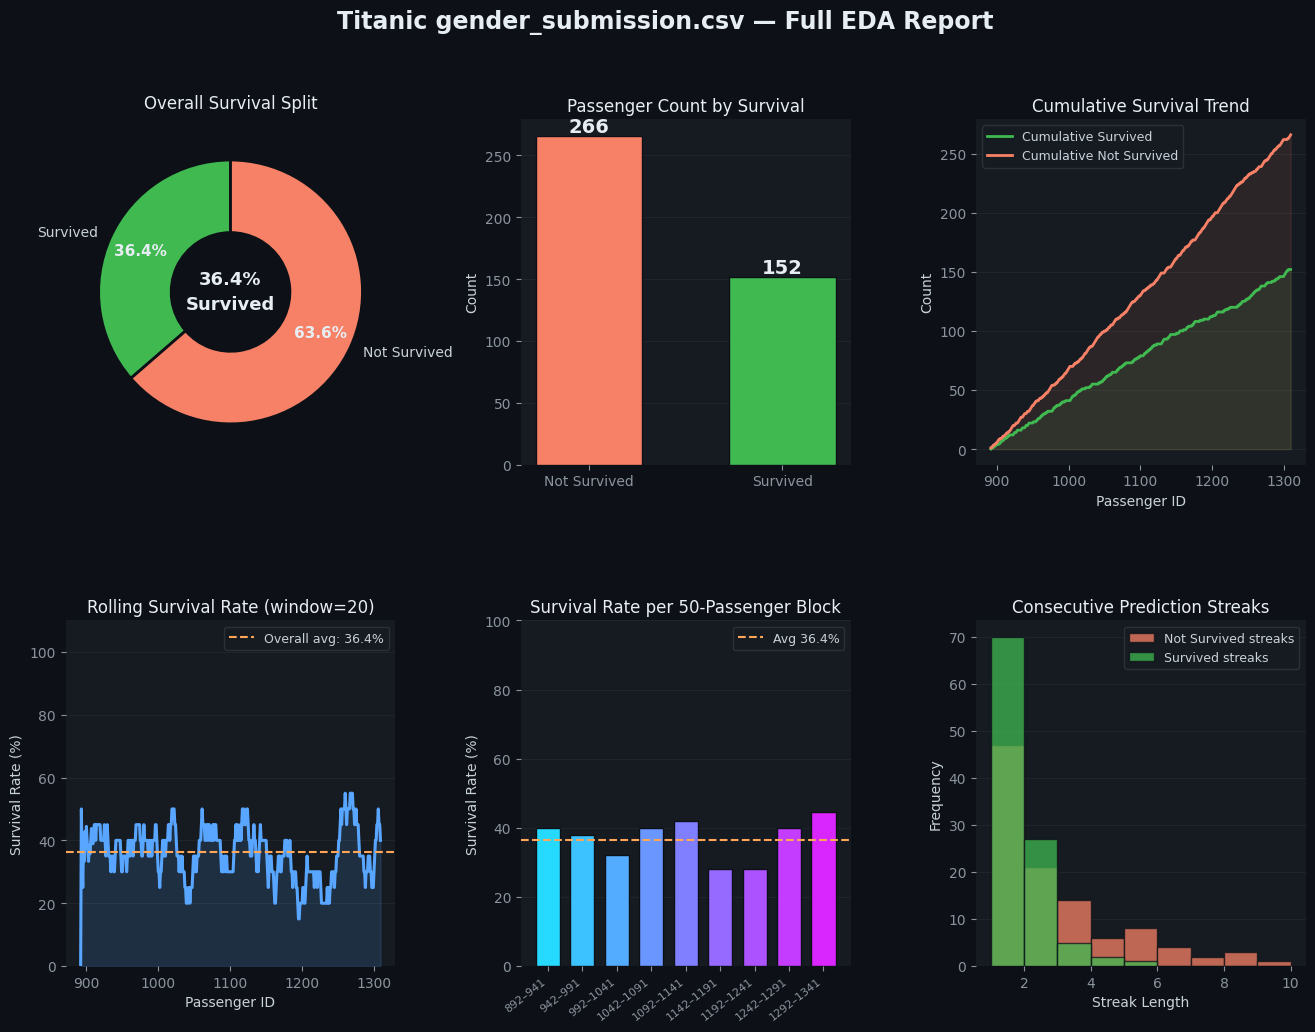

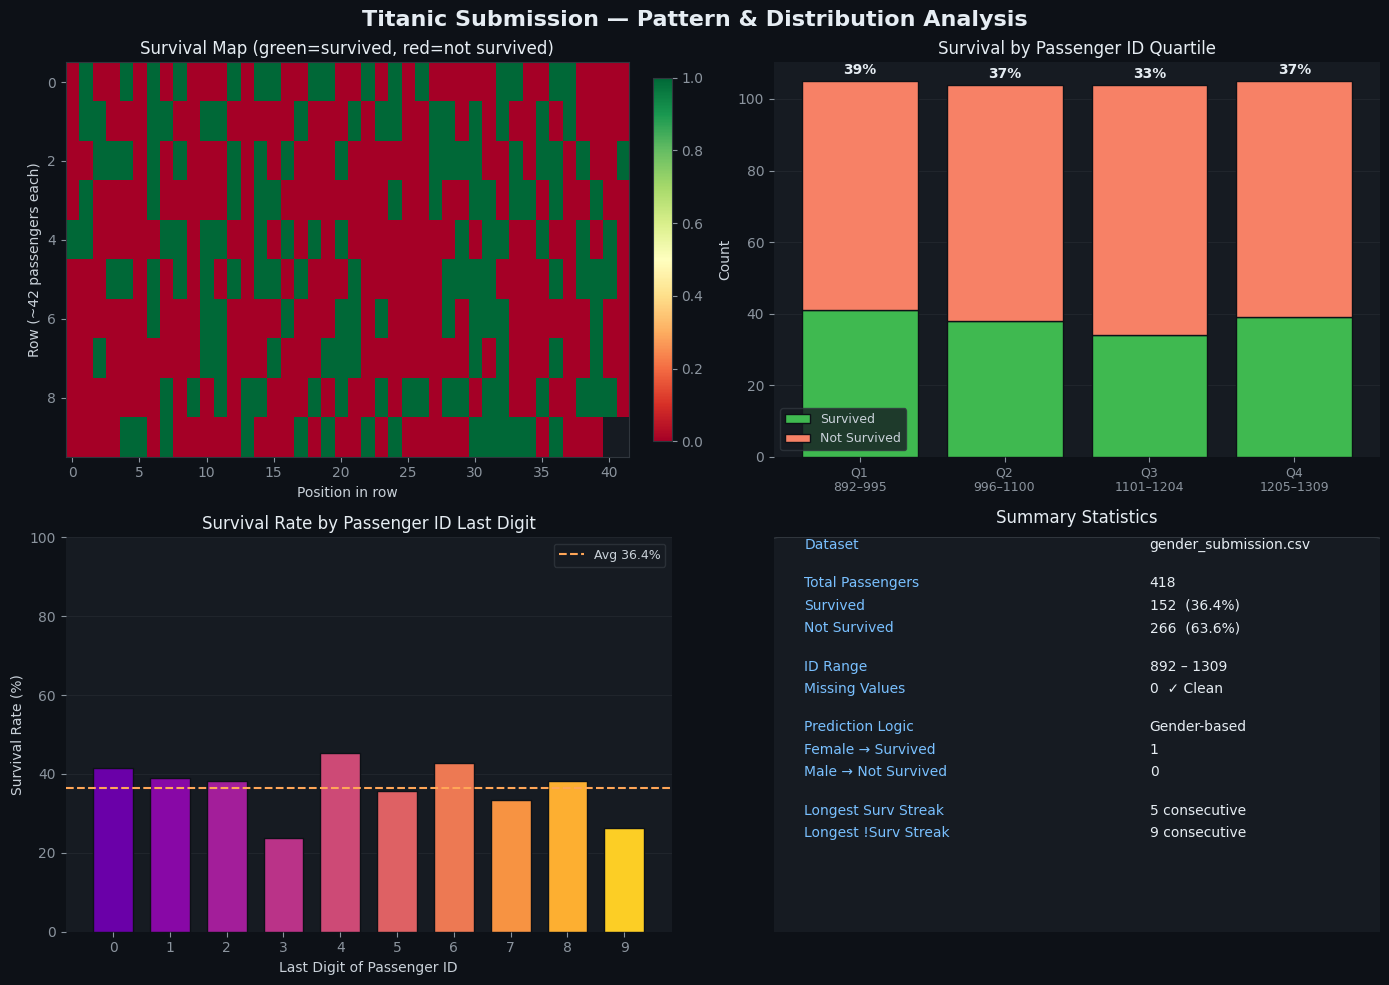


  KEY FINDINGS
  Survival Rate         : 36.4%  (152 / 418)
  Not Survived          : 63.6%  (266 / 418)
  Prediction Logic      : Gender-based (female=1, male=0)
  Missing Values        : None — perfectly clean
  Longest Surv Streak   : 5 consecutive
  Longest !Surv Streak  : 9 consecutive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'axes.titlecolor':'#e6edf3','axes.titlesize':12,'axes.labelsize':10,
    'xtick.color':'#8b949e','ytick.color':'#8b949e','text.color':'#c9d1d9',
    'grid.color':'#21262d','grid.linewidth':0.7,'font.family':'DejaVu Sans',
    'legend.facecolor':'#161b22','legend.edgecolor':'#30363d',
})
C_BLUE='#58a6ff'; C_RED='#f78166'; C_GREEN='#3fb950'
C_AMBER='#ffa657'; C_VIOLET='#d2a8ff'; C_TEAL='#79c0ff'

# ── Load Data ─────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/refs/heads/main/Task%202/gender_submission.csv'
df = pd.read_csv(url)

total     = len(df)
survived  = df['Survived'].sum()
not_surv  = total - survived
surv_rate = survived / total * 100

print("=" * 55)
print("  gender_submission.csv — EDA Report")
print("=" * 55)
print(f"\n  Total Passengers  : {total}")
print(f"  Survived          : {survived} ({surv_rate:.1f}%)")
print(f"  Not Survived      : {not_surv} ({100-surv_rate:.1f}%)")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  PassengerId Range : {df['PassengerId'].min()} – {df['PassengerId'].max()}")

# ── Feature Engineering ───────────────────────────────────────
df_sorted = df.sort_values('PassengerId').reset_index(drop=True)
df_sorted['RollingSurv'] = df_sorted['Survived'].rolling(window=20, min_periods=1).mean() * 100
df_sorted['CumSurv']    = df_sorted['Survived'].cumsum()
df_sorted['CumNotSurv'] = (~df_sorted['Survived'].astype(bool)).cumsum()

# Consecutive streaks
runs_0, runs_1 = [], []
cur_val = df_sorted['Survived'].iloc[0]; cur_run = 1
for v in df_sorted['Survived'].iloc[1:]:
    if v == cur_val: cur_run += 1
    else:
        (runs_1 if cur_val==1 else runs_0).append(cur_run)
        cur_val = v; cur_run = 1
(runs_1 if cur_val==1 else runs_0).append(cur_run)

def sax(ax):
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.set_axisbelow(True); ax.yaxis.grid(True)

# ══════════════════════════════════════════════════════════════
# CHART 1 — Dashboard
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('Titanic gender_submission.csv — Full EDA Report',
             fontsize=17, fontweight='bold', color='#e6edf3', y=0.98)

# 1a. Donut
ax = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax.pie(
    [survived, not_surv], labels=['Survived','Not Survived'],
    colors=[C_GREEN, C_RED], autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0d1117', linewidth=2),
    textprops=dict(color='#c9d1d9', fontsize=10), pctdistance=0.75)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(11); at.set_color('#e6edf3')
ax.set_title('Overall Survival Split', pad=14)
ax.text(0, 0, f'{surv_rate:.1f}%\nSurvived', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#e6edf3', linespacing=1.5)

# 1b. Bar count
ax = fig.add_subplot(gs[0, 1])
bars = ax.bar(['Not Survived','Survived'], [not_surv, survived],
              color=[C_RED, C_GREEN], width=0.55, edgecolor='#0d1117')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, str(int(b.get_height())),
            ha='center', fontsize=14, fontweight='bold', color='#e6edf3')
ax.set_title('Passenger Count by Survival'); ax.set_ylabel('Count'); sax(ax)

# 1c. Cumulative line
ax = fig.add_subplot(gs[0, 2])
ax.plot(df_sorted['PassengerId'], df_sorted['CumSurv'],
        color=C_GREEN, linewidth=2, label='Cumulative Survived')
ax.plot(df_sorted['PassengerId'], df_sorted['CumNotSurv'],
        color=C_RED, linewidth=2, label='Cumulative Not Survived')
ax.fill_between(df_sorted['PassengerId'], df_sorted['CumSurv'], alpha=0.1, color=C_GREEN)
ax.fill_between(df_sorted['PassengerId'], df_sorted['CumNotSurv'], alpha=0.1, color=C_RED)
ax.set_title('Cumulative Survival Trend')
ax.set_xlabel('Passenger ID'); ax.set_ylabel('Count')
ax.legend(fontsize=9, labelcolor='#c9d1d9'); sax(ax)

# 1d. Rolling survival rate
ax = fig.add_subplot(gs[1, 0])
ax.plot(df_sorted['PassengerId'], df_sorted['RollingSurv'], color=C_BLUE, linewidth=2.2)
ax.fill_between(df_sorted['PassengerId'], df_sorted['RollingSurv'], alpha=0.15, color=C_BLUE)
ax.axhline(surv_rate, color=C_AMBER, linewidth=1.5, linestyle='--', label=f'Overall avg: {surv_rate:.1f}%')
ax.set_title('Rolling Survival Rate (window=20)')
ax.set_xlabel('Passenger ID'); ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 110); ax.legend(fontsize=9); sax(ax)

# 1e. Survival per 50-ID block
ax = fig.add_subplot(gs[1, 1])
df['Block50'] = ((df['PassengerId'] - df['PassengerId'].min()) // 50)
block_surv = df.groupby('Block50')['Survived'].mean() * 100
block_labels = [f'{892+i*50}–{892+i*50+49}' for i in block_surv.index]
ax.bar(range(len(block_surv)), block_surv.values,
       color=plt.cm.cool(np.linspace(0.15, 0.85, len(block_surv))),
       edgecolor='#0d1117', width=0.7)
ax.set_xticks(range(len(block_surv)))
ax.set_xticklabels(block_labels, rotation=38, ha='right', fontsize=8)
ax.axhline(surv_rate, color=C_AMBER, linewidth=1.5, linestyle='--', label=f'Avg {surv_rate:.1f}%')
ax.set_title('Survival Rate per 50-Passenger Block')
ax.set_ylabel('Survival Rate (%)'); ax.set_ylim(0, 100)
ax.legend(fontsize=9); sax(ax)

# 1f. Streak histogram
ax = fig.add_subplot(gs[1, 2])
bins = range(1, max(max(runs_0, default=1), max(runs_1, default=1)) + 2)
ax.hist(runs_0, bins=bins, alpha=0.75, color=C_RED, label='Not Survived streaks', edgecolor='#0d1117')
ax.hist(runs_1, bins=bins, alpha=0.75, color=C_GREEN, label='Survived streaks', edgecolor='#0d1117')
ax.set_title('Consecutive Prediction Streaks')
ax.set_xlabel('Streak Length'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9, labelcolor='#c9d1d9'); sax(ax)

plt.show()

# ══════════════════════════════════════════════════════════════
# CHART 2 — Pattern Analysis
# ══════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.patch.set_facecolor('#0d1117')
fig2.suptitle('Titanic Submission — Pattern & Distribution Analysis',
              fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)

# 2a. Survival heatmap
ax = axes[0, 0]
grid_data = df_sorted['Survived'].values
pad = (-len(grid_data)) % 42
grid_2d = np.concatenate([grid_data, np.full(pad, np.nan)]).reshape(-1, 42)
im = ax.imshow(grid_2d, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1,
               interpolation='nearest')
ax.set_title('Survival Map (green=survived, red=not survived)')
ax.set_xlabel('Position in row'); ax.set_ylabel('Row (~42 passengers each)')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

# 2b. Stacked bar by quartile
ax = axes[0, 1]
df['Quarter'] = pd.qcut(df['PassengerId'], 4,
                         labels=['Q1\n892–995','Q2\n996–1100',
                                 'Q3\n1101–1204','Q4\n1205–1309'])
q_surv = df.groupby('Quarter', observed=True)['Survived'].sum()
q_not  = df.groupby('Quarter', observed=True)['Survived'].apply(lambda x: (x==0).sum())
x = np.arange(4)
ax.bar(x, q_surv.values, label='Survived',     color=C_GREEN, edgecolor='#0d1117')
ax.bar(x, q_not.values,  label='Not Survived', color=C_RED,   edgecolor='#0d1117',
       bottom=q_surv.values)
ax.set_xticks(x)
ax.set_xticklabels(['Q1\n892–995','Q2\n996–1100','Q3\n1101–1204','Q4\n1205–1309'], fontsize=9)
for i, (s, n) in enumerate(zip(q_surv.values, q_not.values)):
    ax.text(i, s+n+2, f'{s/(s+n)*100:.0f}%', ha='center',
            fontsize=10, fontweight='bold', color='#e6edf3')
ax.set_title('Survival by Passenger ID Quartile')
ax.set_ylabel('Count'); ax.legend(labelcolor='#c9d1d9', fontsize=9); sax(ax)

# 2c. Last digit pattern
ax = axes[1, 0]
df['LastDigit'] = df['PassengerId'] % 10
ld_surv = df.groupby('LastDigit')['Survived'].mean() * 100
ax.bar(ld_surv.index, ld_surv.values,
       color=plt.cm.plasma(np.linspace(0.2, 0.9, 10)),
       edgecolor='#0d1117', width=0.7)
ax.axhline(surv_rate, color=C_AMBER, linewidth=1.5, linestyle='--', label=f'Avg {surv_rate:.1f}%')
ax.set_title('Survival Rate by Passenger ID Last Digit')
ax.set_xlabel('Last Digit of Passenger ID')
ax.set_ylabel('Survival Rate (%)'); ax.set_xticks(range(10))
ax.set_ylim(0, 100); ax.legend(fontsize=9); sax(ax)

# 2d. Summary stats panel
ax = axes[1, 1]
ax.axis('off')
stats = [
    ("Dataset",            "gender_submission.csv"),
    ("", ""),
    ("Total Passengers",   f"{total}"),
    ("Survived",           f"{survived}  ({surv_rate:.1f}%)"),
    ("Not Survived",       f"{not_surv}  ({100-surv_rate:.1f}%)"),
    ("", ""),
    ("ID Range",           f"{df['PassengerId'].min()} – {df['PassengerId'].max()}"),
    ("Missing Values",     "0  ✓ Clean"),
    ("", ""),
    ("Prediction Logic",   "Gender-based"),
    ("Female → Survived",  "1"),
    ("Male → Not Survived","0"),
    ("", ""),
    ("Longest Surv Streak",    f"{max(runs_1, default=0)} consecutive"),
    ("Longest !Surv Streak",   f"{max(runs_0, default=0)} consecutive"),
]
y = 0.97
for label, value in stats:
    if not label: y -= 0.04; continue
    ax.text(0.05, y, label, transform=ax.transAxes, fontsize=10, color=C_TEAL)
    ax.text(0.62, y, value, transform=ax.transAxes, fontsize=10, color='#e6edf3')
    y -= 0.057
ax.set_title('Summary Statistics', color='#e6edf3', fontsize=12, pad=10)
ax.add_patch(mpatches.FancyBboxPatch((0.01, 0.01), 0.98, 0.97,
    boxstyle="round,pad=0.02", linewidth=1, edgecolor='#30363d',
    facecolor='#161b22', transform=ax.transAxes, zorder=0))

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print("  KEY FINDINGS")
print("="*55)
print(f"  Survival Rate         : {surv_rate:.1f}%  (152 / 418)")
print(f"  Not Survived          : {100-surv_rate:.1f}%  (266 / 418)")
print(f"  Prediction Logic      : Gender-based (female=1, male=0)")
print(f"  Missing Values        : None — perfectly clean")
print(f"  Longest Surv Streak   : {max(runs_1, default=0)} consecutive")
print(f"  Longest !Surv Streak  : {max(runs_0, default=0)} consecutive")
